In [1]:
import cornac
from cornac.data import Reader
from cornac.datasets import movielens
from cornac.data import Dataset, FeatureModality
from cornac.eval_methods import RatioSplit, StratifiedSplit
from cornac.metrics import RMSE,AUC,NDCG,Precision,Recall
from cornac.models import MF, ItemKNN, UserKNN, NMF, BPR
import pandas as pd
import numpy as np

import math
import seaborn as sns
import matplotlib.pyplot as plt

/Users/tahsinalamgirkheya/anaconda3/envs/cornac/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
reader = Reader()
rating_data = pd.read_csv(
    "./cornac/data_c/indexed_interactions.csv",
    sep="\t",
    header=None,
    names=["userID", "itemID", "Rating", "Timestamp"],
)
print(rating_data["itemID"].nunique())
# rating_data = rating_data.drop(columns=rating_data.columns[-1])
rating_data = rating_data.to_numpy()
rating_data
# user id itemid rating and timestamp

3416


array([[        0,         0,         5, 978300760],
       [        0,         1,         3, 978302109],
       [        0,         2,         3, 978301968],
       ...,
       [     6039,       365,         5, 956704746],
       [     6039,       152,         4, 956715648],
       [     6039,        26,         4, 956715569]])

In [3]:
# dataset = Dataset.from_uirt(rating_data, reader=reader)
dataset = rating_data

In [4]:
rating_data.shape

(999611, 4)

In [5]:
# movie_data = reader.read(fpath="./data/indexed_movies.csv", sep=",", fmt="UIRT")
# movie_data
movies = pd.read_csv("./cornac/data_c/indexed_movies.csv")

movies = movies.drop(columns=movies.columns[0])
movies[:4]

unique_genres = set("|".join(movies["genres"]).split("|"))
unique_genres = list(unique_genres)

for genre in unique_genres:
    movies[genre] = 0
for index, row in movies.iterrows():
    genres = row["genres"].split("|")
    for genre in genres:
        movies.at[index, genre] = 1

# item_categories = movies[unique_genres]
genre = movies[unique_genres]
item_features_numpy = genre.to_numpy()
# print(item_features_numpy.shape)

# item_categories = item_categor
item_features = {
    str(item_id): {"genre_" + str(idx): value for idx, value in enumerate(row)}
    for item_id, row in enumerate(item_features_numpy)
}
ids = list(range(0, 3416))
item_feature_modality = FeatureModality(
    features=item_features_numpy, ids=ids, normalized=True
)
item_feature_modality.__getstate__()
users = pd.read_csv("./cornac/data_c/u_id_mapping.csv", sep="\t")
users = users.drop(columns=users.columns[0])
gender_map = {"M": 0, "F": 1}
users["Gender"] = users["Gender"].map(gender_map)

user_features_numpy = users.to_numpy()
print(user_features_numpy.shape)
user_feature_modality = FeatureModality(
    features=user_features_numpy, name="user", normalized=True, ids=list(range(0, 6040))
)

# print("Example Item Features:")
# for item_id, features in list(item_features.items())[:5]:
#     print(f"Item ID: {item_id}, Features: {features}")

(6040, 2)


In [6]:
item_features_numpy

array([[1, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0]])

In [7]:
# dataset.add_modalities(user_feature=user_feature_modality, item_features=item_feature_modality )
user_features_numpy

array([[   0,    1],
       [   1,    0],
       [   2,    0],
       ...,
       [6037,    1],
       [6038,    1],
       [6039,    0]])

In [32]:
ratio_split = StratifiedSplit(
    data=dataset,
    test_size=0.2,
    rating_threshold=0.0,
    seed=123,
    verbose=True,
    chrono=True,
    user_features=user_features_numpy[:, 1],
    item_features=item_features_numpy,exclude_unknowns=False
)
rec_20 = cornac.metrics.Recall(k=20)
ndcg_20 = cornac.metrics.NDCG(k=20)
auc = cornac.metrics.AUC()
rmse = cornac.metrics.RMSE()


models=[]
# alpha_values=[ 1.0, 1000.0,10, 10000.0]
alpha_values=[0,0.8]
# for i in range(len(alpha_values)):
model = MF(
k=10,
max_iter=50,
learning_rate=0.0001,
lambda_reg=0.02,
seed=123,
name="alpha="+str(alpha_values[0]),
backend="pytorch",
alpha=alpha_values[0],
optimizer="sgd"
)    
model_2 = MF(
k=10,
max_iter=50,
learning_rate=0.0001,
lambda_reg=0.02,
seed=123,
name="alpha="+str(alpha_values[1]),
backend="pytorch",
optimizer="sgd",
alpha=alpha_values[1],
) 
# model_3 = MF(
# k=10,
# max_iter=50,
# learning_rate=0.0001,
# lambda_reg=0.02,
# seed=123,
# name="alpha="+str(alpha_values[2]),
# optimizer="adam",
# backend="pytorch",
# alpha=alpha_values[2]
# ) 
# model_4 = MF(
# k=10,
# max_iter=50,
# learning_rate=0.0001,
# optimizer="adam",
# lambda_reg=0.02,
# seed=123,
# name="alpha="+str(alpha_values[3]),
# backend="pytorch",
# alpha=alpha_values[3]
# ) 
    # models.append(model)


cornac.Experiment(
    ratio_split, models=[model, model_2], metrics=[rec_20,ndcg_20,auc,rmse]
).run()

rating_threshold = 0.0
exclude_unknowns = False
::::::::
OrderedDict()
OrderedDict()
::::::::
---
Training data:
Number of users = 6040
Number of items = 3415
Number of ratings = 797275
Max rating = 5.0
Min rating = 1.0
Global mean = 3.6
::::::::
OrderedDict([(6039, 0), (6038, 1), (6037, 2), (6036, 3), (6035, 4), (6034, 5), (6033, 6), (6032, 7), (6031, 8), (6030, 9), (6029, 10), (6028, 11), (6027, 12), (6026, 13), (6025, 14), (6024, 15), (6023, 16), (6022, 17), (6021, 18), (6020, 19), (6019, 20), (6018, 21), (6017, 22), (6016, 23), (6015, 24), (6014, 25), (6013, 26), (6012, 27), (6011, 28), (6010, 29), (6009, 30), (6008, 31), (6006, 32), (6007, 33), (6005, 34), (6004, 35), (6003, 36), (6002, 37), (6001, 38), (6000, 39), (5999, 40), (5998, 41), (5997, 42), (5996, 43), (5995, 44), (5994, 45), (5993, 46), (5992, 47), (5991, 48), (5990, 49), (5989, 50), (5988, 51), (5987, 52), (5986, 53), (5985, 54), (5983, 55), (5982, 56), (5981, 57), (5980, 58), (5978, 59), (5979, 60), (5977, 61), (5976,

100%|██████████| 50/50 [02:13<00:00,  2.68s/it, loss=0.00464]



[alpha=0] Evaluation started!


Ranking: 100%|██████████| 6040/6040 [00:03<00:00, 1818.08it/s]



[alpha=0.8] Training started!


100%|██████████| 50/50 [03:22<00:00,  4.05s/it, loss=0.00102] 



[alpha=0.8] Evaluation started!


Ranking: 100%|██████████| 6040/6040 [00:02<00:00, 2035.45it/s]


TEST:
...
          |   RMSE |    AUC | NDCG@20 | Recall@20 | Train (s) | Test (s)
--------- + ------ + ------ + ------- + --------- + --------- + --------
alpha=0   | 1.0806 | 0.5811 |  0.1025 |    0.0662 |  133.9978 |   5.5626
alpha=0.8 | 1.0846 | 0.5799 |  0.1002 |    0.0641 |  202.3659 |   4.6568



In [9]:
model.get_user_vectors() == model_2.get_user_vectors() 


array([[False, False, False, ..., False, False,  True],
       [False, False, False, ..., False, False,  True],
       [False, False, False, ..., False, False,  True],
       ...,
       [False, False, False, ..., False, False,  True],
       [False, False, False, ..., False, False,  True],
       [False, False, False, ..., False, False,  True]])

In [10]:
          |    AUC | NDCG@20 | Recall@20 | Train (s) |  Test (s)
--------- + ------ + ------- + --------- + --------- + ---------
alpha=0   | 0.5589 |  0.0527 |    0.0276 |  523.2460 |    2.5187
alpha=0.5 | 0.5621 |  0.0526 |    0.0279 | 3233.0966 | 1039.3472
alpha=0.8 | 0.6195 |  0.0962 |    0.0607 | 3889.4446 |    2.4321
alpha=0.9 | 0.6174 |  0.0962 |    0.0606 |  227.9855 |    2.6400

SyntaxError: invalid syntax (4065337240.py, line 1)

In [ ]:
model.get_item_vectors() == model_2.get_item_vectors() 


array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

In [ ]:
for p1,p2 in zip(model.par)
model.

SyntaxError: expected ':' (1377793.py, line 1)

In [33]:
models=[model,model_2]

In [34]:
user_ids = users.to_numpy()[:, 0]
item_ids = movies.to_numpy()[:, 2]

In [28]:
# get the top_k ratings for all users:
top_k = 50
reco_matrix = np.zeros((len(user_ids), top_k), dtype=int)

for u in user_ids:
    reco_items, all_scores = model.rank(user_idx=u, item_indices=list(item_ids))
    reco_matrix[u] = reco_items[:top_k]

In [ ]:
# get the top_k ratings for all users:
top_k = 50
reco_matrix_2 = np.zeros((len(user_ids), top_k), dtype=int)

for u in user_ids:
    reco_items, all_scores = model_2.rank(user_idx=u, item_indices=list(item_ids))
    reco_matrix_2[u] = reco_items[:top_k]

In [35]:
# get the top_k ratings for all users:
top_k = 50
reco_matrix = np.zeros((len(models), len(user_ids), top_k), dtype=int)


for u in user_ids:
    for i in range(len(models)):
        reco_items, all_scores = models[i].rank(user_idx=u, item_indices=list(item_ids))
        reco_matrix[i][u] = reco_items[:top_k]

In [ ]:
reco_matrix[0]

array([[  28,   16,  649, ...,    4, 1574,  801],
       [  28,   16,  649, ...,  441,    1,  636],
       [  28,   16,  649, ..., 1255, 1398,  636],
       ...,
       [  28,   16,  649, ..., 2075, 1699, 1040],
       [  28,   16,  649, ..., 1794, 1169, 1699],
       [  28,   16,  649, ...,  540, 1169,   44]])

In [ ]:
reco_matrix[1]

array([[  28, 1086, 1094, ..., 1529,  466, 1556],
       [  28,   16, 1086, ...,  981,  412, 1189],
       [  28,   16, 1086, ..., 1251,  412, 1189],
       ...,
       [  28, 1086,   16, ...,  968,  915, 1220],
       [  28,   16, 1086, ...,  412, 1251, 1901],
       [  28, 1086,   16, ...,   50,  968,  934]])

In [ ]:
reco_matrix[0].__len__()

6040

In [ ]:
####IR Metrics####
####Precision####
from cornac.mymetrics.GenrePrecision import GenrePrecision

gp = GenrePrecision(users, unique_genres)
# MF_gp = gp.compute(reco_matrix, movies)
MF_gp=[0]*2
MF_gp[0] = gp.compute(reco_matrix, movies)
MF_gp[1] = gp.compute(reco_matrix_2, movies)

In [ ]:
MF_gp

[array([1.82649774e-04, 1.05297055e-04, 9.76550050e-05, 1.88295791e-04,
        5.05831177e-05, 1.69650697e-05, 2.78391790e-05, 2.98947036e-04,
        5.25652355e-05, 4.07467144e-04, 4.77083195e-05, 1.02790191e-04,
        1.69794808e-04, 3.99940788e-06, 1.49049515e-04, 9.19557126e-05,
        7.03263859e-05, 2.89811361e-04]),
 array([1.82649774e-04, 1.05297055e-04, 9.76550050e-05, 1.88295791e-04,
        5.05831177e-05, 1.69650697e-05, 2.78391790e-05, 2.98947036e-04,
        5.25652355e-05, 4.07467144e-04, 4.77083195e-05, 1.02790191e-04,
        1.69794808e-04, 3.99940788e-06, 1.49049515e-04, 9.19557126e-05,
        7.03263859e-05, 2.89811361e-04])]

In [ ]:
for i in range(len(models)):
    print(sum(MF_gp[i]))

In [36]:
####IR Metrics####
####MAP Mean Average Precision####
from cornac.mymetrics.GenreMap import GenreMap

gm = GenreMap(users, unique_genres)
MF_gm=[0]*len(models)
for i in range(len(models)):
    MF_gm[i] = gm.compute(reco_matrix[i], movies)

In [ ]:
####IR Metrics####
####MAP Mean Average Precision####
from cornac.mymetrics.GenreMap import GenreMap

gm = GenreMap(users, unique_genres)
MF_gm = gm.compute(reco_matrix, movies)
print(sum(MF_gm))

0.00011478796197304394


In [ ]:
for i in range(3):
    print(sum(MF_gm[i]))

0.0003215630557355577
0.0003215630557355577
0.0003215630557355577


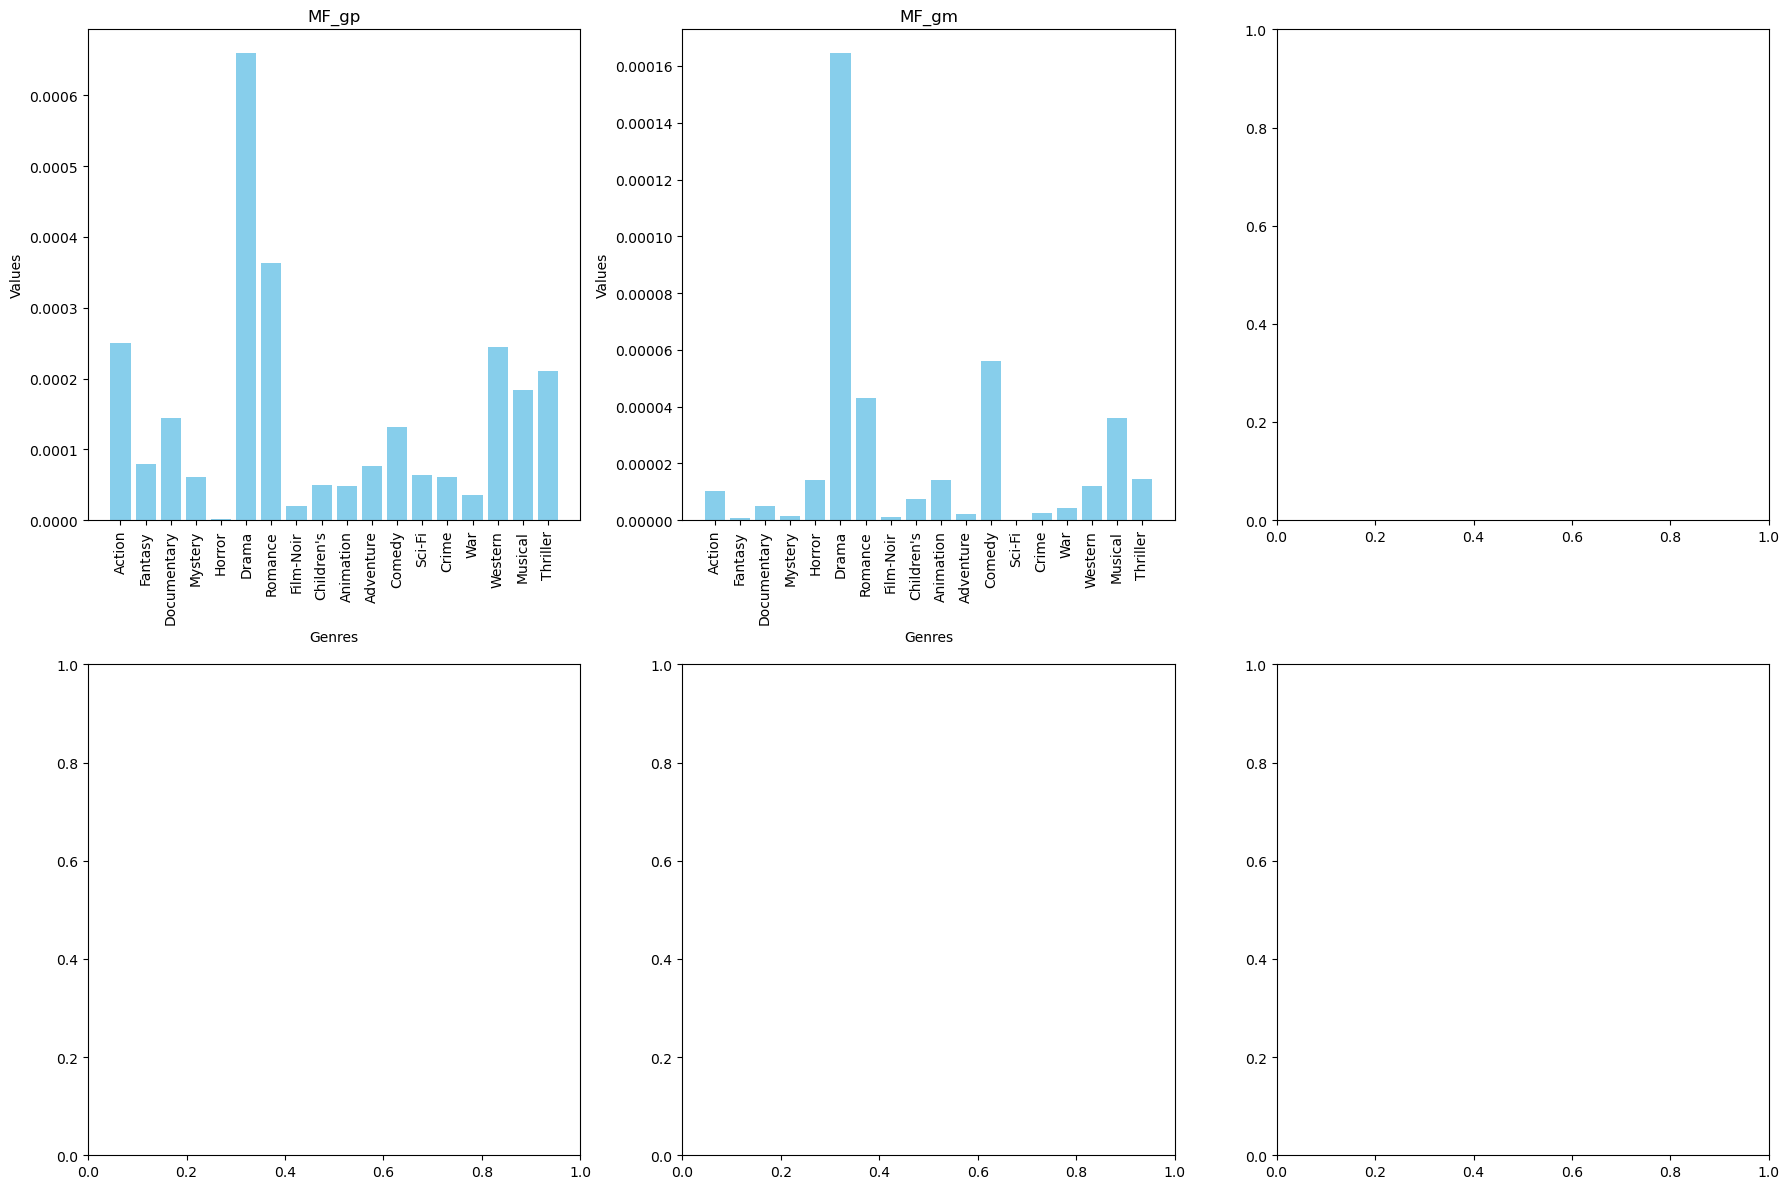

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

matrices = [MF_gp, MF_gm]


values1 = matrices[0]
values2 = matrices[1]
labels = unique_genres
bar_width = 0.25
titles = ["MF_gp", "MF_gm"]


fig, axs = plt.subplots(2, 3, figsize=(18, 12))
axs = axs.flatten()


for i in range(len(matrices)):
    axs[i].bar(labels, matrices[i], color="skyblue")
    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Genres")
    axs[i].set_ylabel("Values")
    axs[i].tick_params(axis="x", rotation=90)

# Adjust layout
plt.tight_layout()
plt.show()

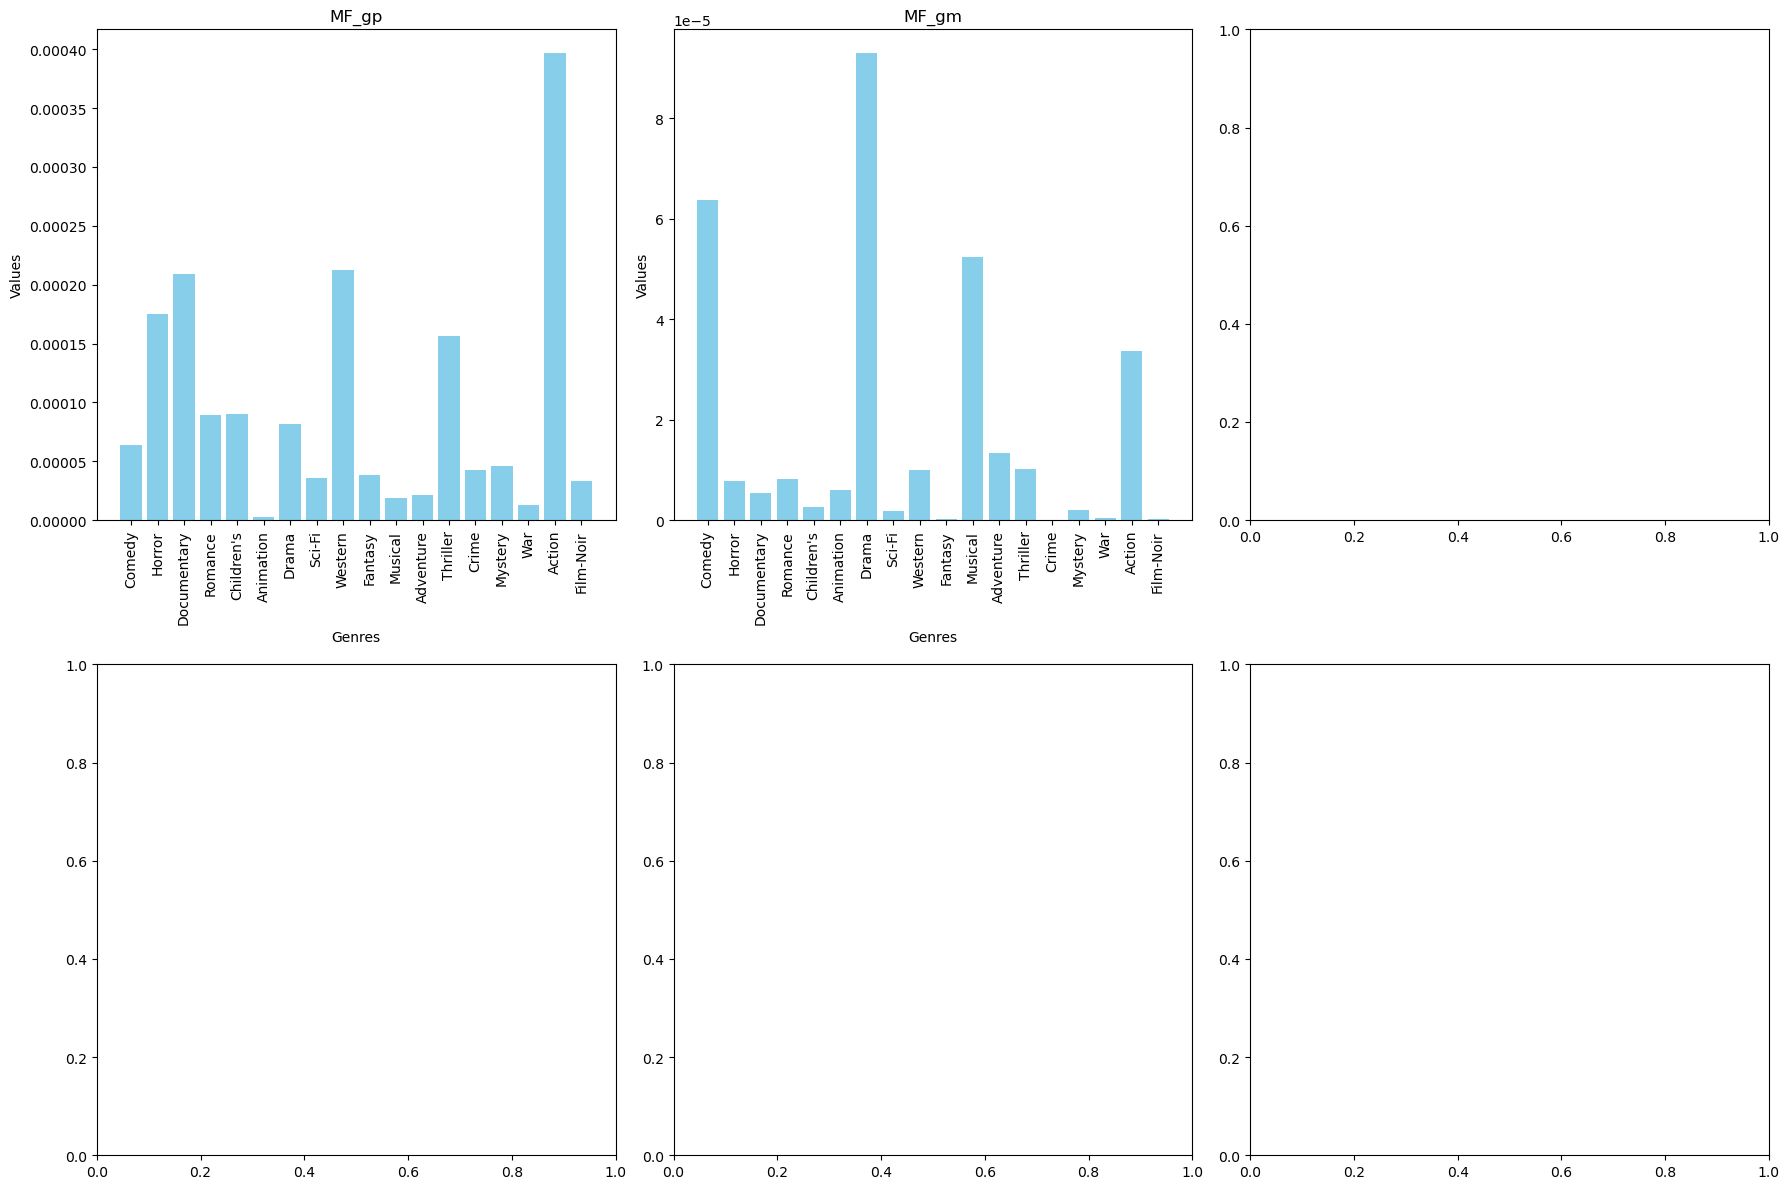

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

matrices = [MF_gp, MF_gm]


values1 = matrices[0]
values2 = matrices[1]
labels = unique_genres
bar_width = 0.25
titles = ["MF_gp", "MF_gm"]


fig, axs = plt.subplots(2, 3, figsize=(18, 12))
axs = axs.flatten()


for i in range(len(matrices)):
    axs[i].bar(labels, matrices[i], color="skyblue")
    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Genres")
    axs[i].set_ylabel("Values")
    axs[i].tick_params(axis="x", rotation=90)

# Adjust layout
plt.tight_layout()
plt.show()

In [39]:
print(sum(MF_gm[0]))
print(sum(MF_gm[1]))

2.5945509491927932e-05
0.00021900175451046607


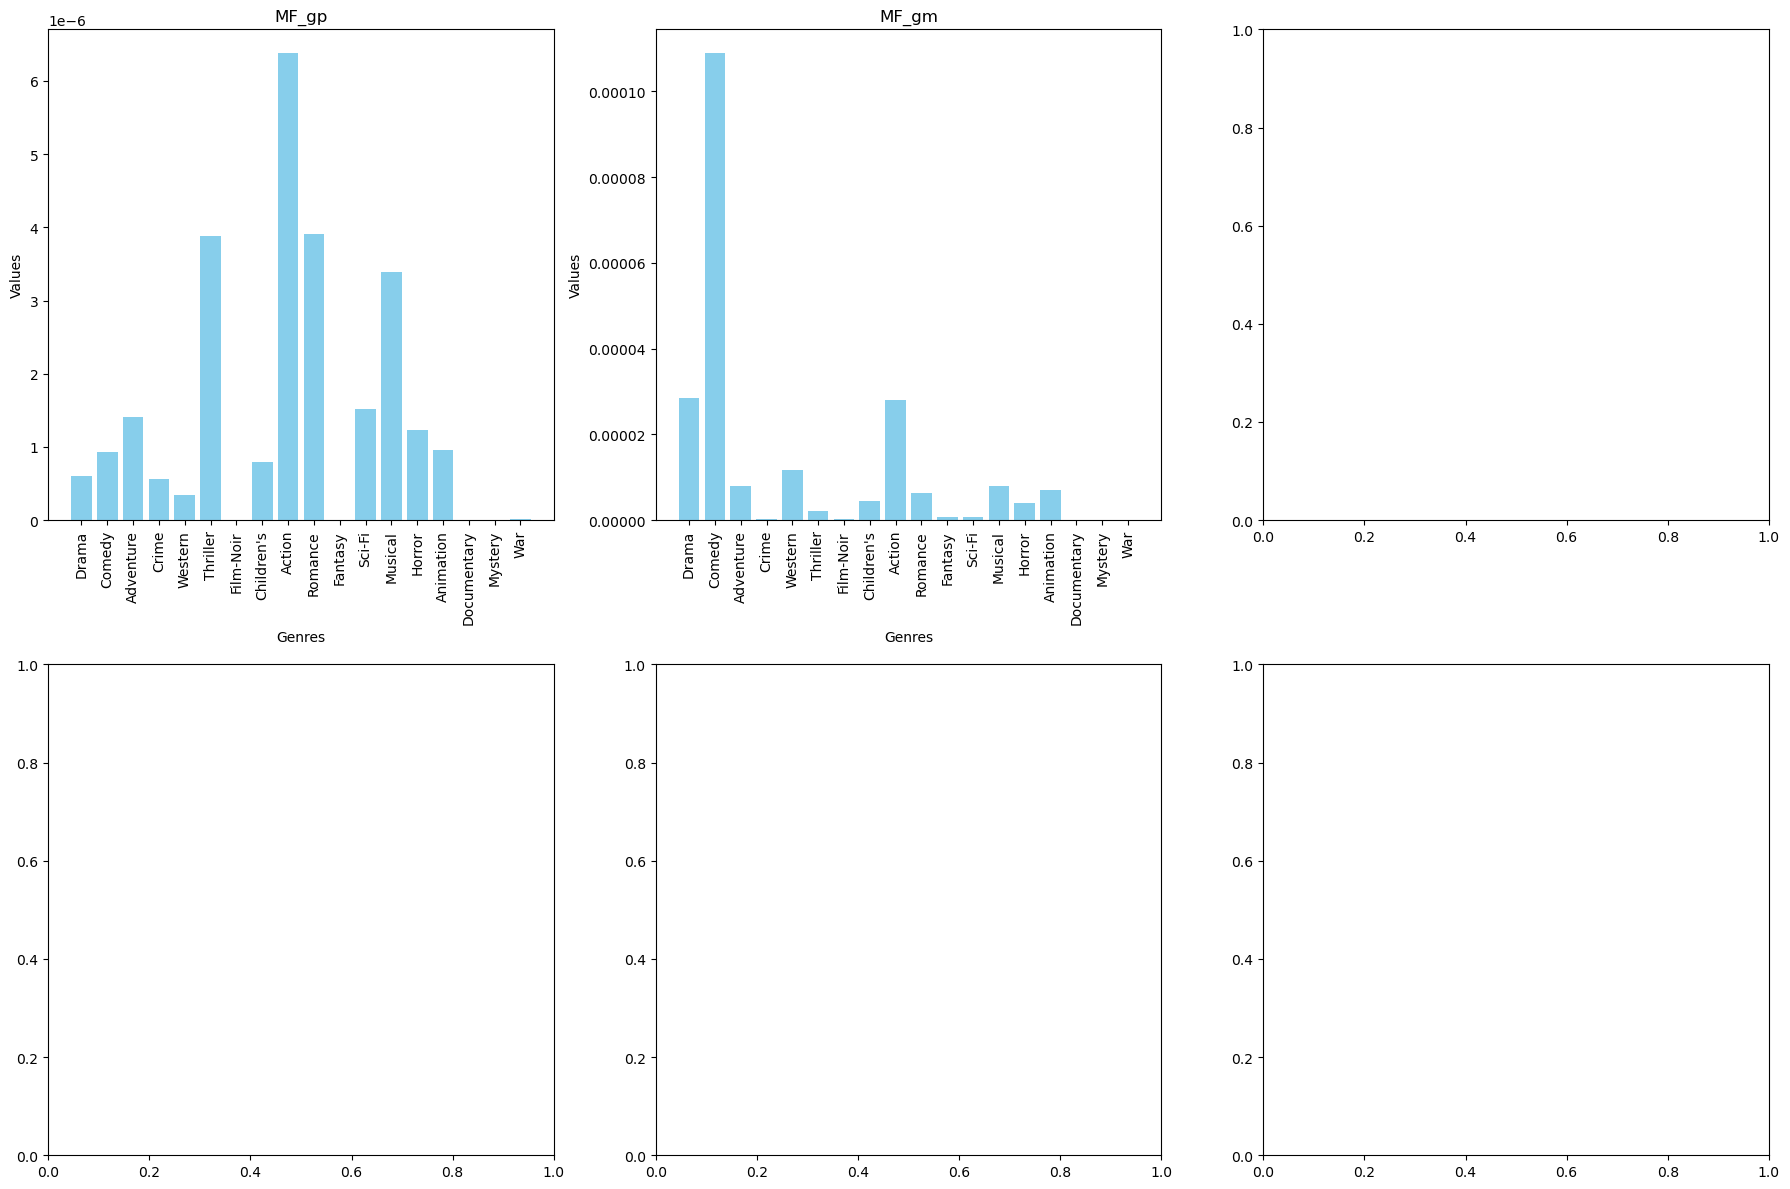

In [37]:
import matplotlib.pyplot as plt
import numpy as np

matrices = [MF_gm[0], MF_gm[1]]


values1 = matrices[0]
values2 = matrices[1]
# values3 = matrices[2]
labels = unique_genres
bar_width = 0.25
titles = ["MF_gp", "MF_gm"]


fig, axs = plt.subplots(2, 3, figsize=(18, 12))
axs = axs.flatten()


for i in range(len(matrices)):
    axs[i].bar(labels, matrices[i], color="skyblue")
    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Genres")
    axs[i].set_ylabel("Values")
    axs[i].tick_params(axis="x", rotation=90)

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
print(type(user_features_numpy[:, 1]))

In [ ]:
print(user_features_numpy[:, 1].shape)

In [ ]:
items

In [ ]:
movies

In [ ]:
rating_data.__len__()


In [ ]:
model_4 = MF(
k=10,
max_iter=50,
learning_rate=0.001,
lambda_reg=0.02,
seed=123,
name="alpha="+str(50),
backend="pytorch",
alpha=50
) 
    # models.append(model)


cornac.Experiment(
    ratio_split, models=[model_4], metrics=[cornac.metrics.RMSE(), cornac.metrics.AUC(), cornac.metrics.NDCG]
).run()


[alpha=50] Training started!


100%|██████████| 50/50 [01:53<00:00,  2.27s/it, loss=0.661]



[alpha=50] Evaluation started!


Ranking: 100%|██████████| 6040/6040 [00:03<00:00, 1984.16it/s]


TEST:
...
         |   RMSE |    AUC | Train (s) | Test (s)
-------- + ------ + ------ + --------- + --------
alpha=50 | 1.0366 | 0.5739 |  113.7054 |   4.1428



In [ ]:
# get the top_k ratings for all users:
top_k = 50
reco_matrix_4 = np.zeros((len(user_ids), top_k), dtype=int)

for u in user_ids:
    reco_items, all_scores = model.rank(user_idx=u, item_indices=list(item_ids))
    reco_matrix_4[u] = reco_items[:top_k]